# TSF vs CPS — dados contínuos reais

Comparação probabilística em duas séries públicas reais: AirPassengers e temperaturas mínimas diárias de Melbourne. Para o TSF é usada a família Weibull, adequada ao suporte estritamente positivo observado.

In [1]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from sklearn.ensemble import HistGradientBoostingRegressor

from tinyshift.forecasting import (
    NegativeBinomialFamily,
    TwoStageForecasterWrapper,
    WeibullFamily,
)
from tinyconformal.series import (
    ContinuousTimeSeriesConformalPredictiveSystem,
    DiscreteTimeSeriesConformalPredictiveSystem,
)

SEED = 42
H = 14
N_WINDOWS = 5
LEVEL = 0.90
DATA_DIR = Path("data/tsf_cps")
DATA_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

print({"tinyshift": version("tinyshift"), "tinyconformal": version("tinyconformal")})

{'tinyshift': '1.7.7', 'tinyconformal': '0.5.4'}


In [2]:
def make_forecaster(freq, lags):
    model = LGBMRegressor(
        n_estimators=120, learning_rate=0.05, num_leaves=15,
        verbosity=-1, random_state=SEED, n_jobs=1,
    )
    return MLForecast(models={"LGBM": model}, freq=freq, lags=lags)


def fit_tsf(train, freq, lags, family, h=H, n_windows=N_WINDOWS):
    model = TwoStageForecasterWrapper(make_forecaster(freq, lags), distribution=family)
    tic = perf_counter()
    model.fit(train, h=h, n_windows=n_windows, refit=True)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_cps(train, freq, lags, discrete, h=H, n_windows=N_WINDOWS):
    cls = (DiscreteTimeSeriesConformalPredictiveSystem if discrete
           else ContinuousTimeSeriesConformalPredictiveSystem)
    model = cls(
        learner=make_forecaster(freq, lags),
        dispersion_learner=HistGradientBoostingRegressor(
            max_iter=80, max_leaf_nodes=8, random_state=SEED
        ),
        horizon=h, n_windows=n_windows, alpha=1-LEVEL,
    )
    tic = perf_counter()
    model.fit(train, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def prediction_table(forecast, test, level=LEVEL):
    base = forecast.to_frame().copy()
    intervals = forecast.interval(level)
    quantiles = forecast.ppf([0.5])
    out = base.merge(test[["unique_id", "ds", "y"]], on=["unique_id", "ds"], validate="one_to_one")
    # APIs preservam a ordem do painel e nomeiam explicitamente os outputs.
    lo_col = next(c for c in intervals if "-lo-" in c)
    hi_col = next(c for c in intervals if "-hi-" in c)
    median_col = next(c for c in quantiles if "-q-50" in c)
    out["lower"] = intervals[lo_col].to_numpy()
    out["upper"] = intervals[hi_col].to_numpy()
    out["median"] = quantiles[median_col].to_numpy()
    return out


def metrics(table, method, dataset, fit_seconds, predict_seconds, level=LEVEL):
    y = table.y.to_numpy(float)
    lo, hi, pred = (table[c].to_numpy(float) for c in ["lower", "upper", "median"])
    alpha = 1-level
    covered = (y >= lo) & (y <= hi)
    winkler = (hi-lo) + (2/alpha)*(lo-y)*(y < lo) + (2/alpha)*(y-hi)*(y > hi)
    return {
        "dataset": dataset, "method": method,
        "RMSE_mediana": np.sqrt(np.mean((y-pred)**2)),
        "MAE_mediana": np.mean(np.abs(y-pred)),
        "cobertura_90": covered.mean(), "largura_media_90": np.mean(hi-lo),
        "Winkler_90": np.mean(winkler), "fit_s": fit_seconds,
        "predict_s": predict_seconds, "n_teste": len(y),
    }


def plot_intervals(tables, title):
    fig, axes = plt.subplots(len(tables), 1, figsize=(13, 3.6*len(tables)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (name, tab) in zip(axes, tables.items()):
        one = tab[tab.unique_id == tab.unique_id.iloc[0]]
        ax.plot(one.ds, one.y, "o-", color="black", label="observado", ms=3)
        ax.plot(one.ds, one["median"], color="C0", label="mediana")
        ax.fill_between(one.ds, one.lower, one.upper, alpha=.25, label="intervalo 90%")
        ax.set_title(name); ax.legend(ncol=3)
    fig.suptitle(title, y=1.01); plt.tight_layout()


def temporal_split(df, h=H):
    df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
    test = df.groupby("unique_id", group_keys=False).tail(h)
    train = df.drop(test.index).reset_index(drop=True)
    return train, test.reset_index(drop=True)

In [3]:
AIR_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
TEMP_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"


def load_air():
    raw = pd.read_csv(AIR_URL)
    return pd.DataFrame({"unique_id": "AirPassengers", "ds": pd.to_datetime(raw.Month),
                         "y": raw.Passengers.astype(float)})


def load_temperature():
    raw = pd.read_csv(TEMP_URL)
    out = pd.DataFrame({"unique_id": "Melbourne", "ds": pd.to_datetime(raw.Date),
                        "y": pd.to_numeric(raw.Temp, errors="coerce")}).dropna()
    # Conversão física exata °C -> K preserva os dados e satisfaz o suporte Weibull.
    out["y"] = out["y"] + 273.15
    # Mantém o trecho diário contíguo mais longo, sem imputar nem sintetizar observações.
    run = out.ds.diff().ne(pd.Timedelta(days=1)).cumsum()
    longest = run.value_counts().idxmax()
    return out[run.eq(longest)].tail(3*365).reset_index(drop=True)


datasets = {"AirPassengers": load_air(), "Melbourne min temperature": load_temperature()}
for name, frame in datasets.items():
    print(name, frame.shape, frame.ds.min(), frame.ds.max(), "mínimo:", frame.y.min())

AirPassengers (144, 3) 1949-01-01 00:00:00 1960-12-01 00:00:00 mínimo: 104.0
Melbourne min temperature (1095, 3) 1982-01-01 00:00:00 1984-12-30 00:00:00 mínimo: 273.15


## Benchmark temporal

A última janela é teste; todas as janelas anteriores são treino/calibração. O mesmo LightGBM, lags, horizonte e número de janelas são usados por TSF e CPS.

In [4]:
results, predictions = [], {}
for dataset_name, df in datasets.items():
    freq = "MS" if dataset_name == "AirPassengers" else ("h" if "Bike" in dataset_name else "D")
    lags = [1, 12] if freq == "MS" else ([1, 24, 168] if freq == "h" else [1, 7, 28])
    train, test = temporal_split(df)

    tsf, tsf_fc, tsf_fit, tsf_pred = fit_tsf(train, freq, lags, WeibullFamily())
    cps, cps_fc, cps_fit, cps_pred = fit_cps(train, freq, lags, discrete=False)
    tsf_tab = prediction_table(tsf_fc, test)
    cps_tab = prediction_table(cps_fc, test)
    predictions[(dataset_name, "TSF")] = tsf_tab
    predictions[(dataset_name, "CPS")] = cps_tab
    results += [
        metrics(tsf_tab, "TSF", dataset_name, tsf_fit, tsf_pred),
        metrics(cps_tab, "CPS", dataset_name, cps_fit, cps_pred),
    ]

resultados = pd.DataFrame(results)
display(resultados.round(4))
display(resultados.pivot(index="dataset", columns="method",
                         values=["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90", "fit_s"]).round(4))

,dataset,method,RMSE_mediana,MAE_mediana,cobertura_90,largura_media_90,Winkler_90,fit_s,predict_s,n_teste
0,AirPassengers,TSF,70.4406,49.2603,0.8571,327.2905,448.2185,0.2732,0.0238,14
1,AirPassengers,CPS,80.9013,62.2568,0.5714,156.5436,712.9967,0.4210,0.0277,14
2,Melbourne min temperature,TSF,2.1619,1.6764,1.0000,16.1449,16.1449,0.3224,0.0242,14
3,Melbourne min temperature,CPS,2.7562,2.0872,0.8571,8.8322,13.3489,0.4625,0.0275,14


RMSE_mediana          cobertura_90          \
method                             CPS      TSF          CPS     TSF   
dataset                                                                
AirPassengers                  80.9013  70.4406       0.5714  0.8571   
Melbourne min temperature       2.7562   2.1619       0.8571  1.0000   

                          largura_media_90           Winkler_90            \
method                                 CPS       TSF        CPS       TSF   
dataset                                                                     
AirPassengers                     156.5436  327.2905   712.9967  448.2185   
Melbourne min temperature           8.8322   16.1449    13.3489   16.1449   

                            fit_s          
method                        CPS     TSF  
dataset                                    
AirPassengers              0.4210  0.2732  
Melbourne min temperature  0.4625  0.3224

## Visualização e síntese

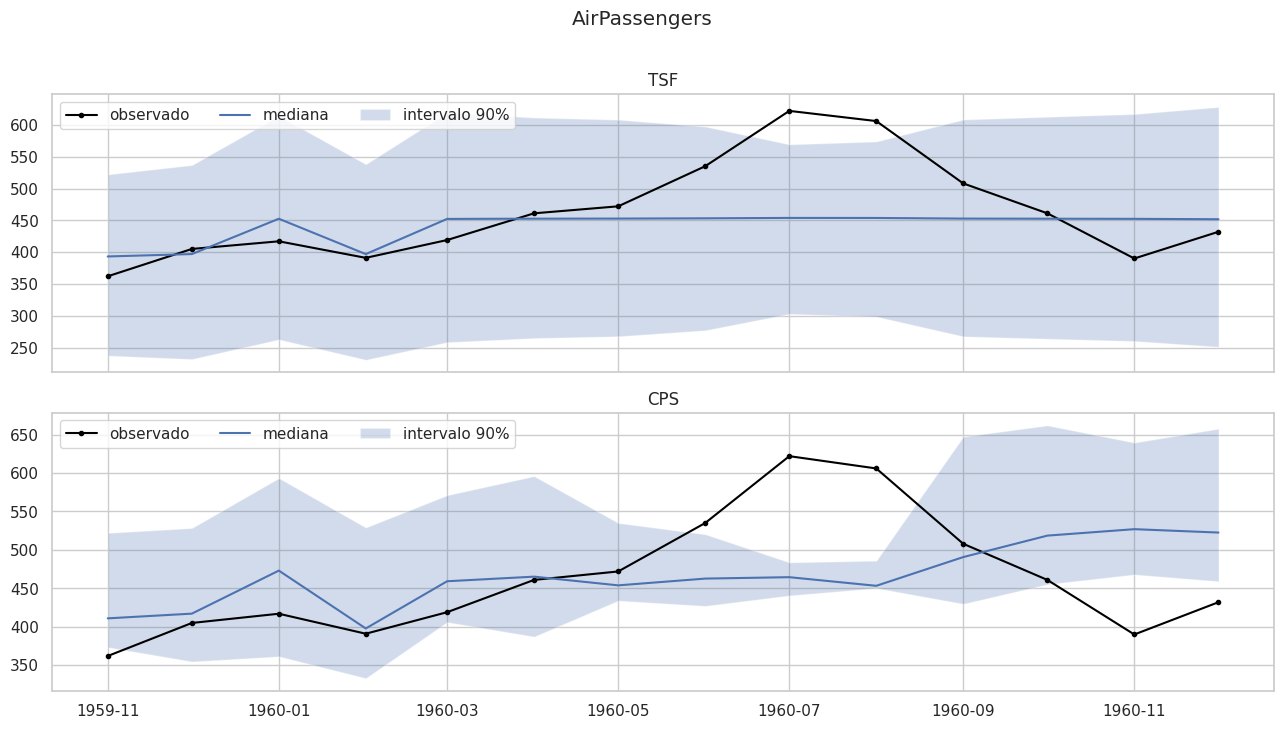

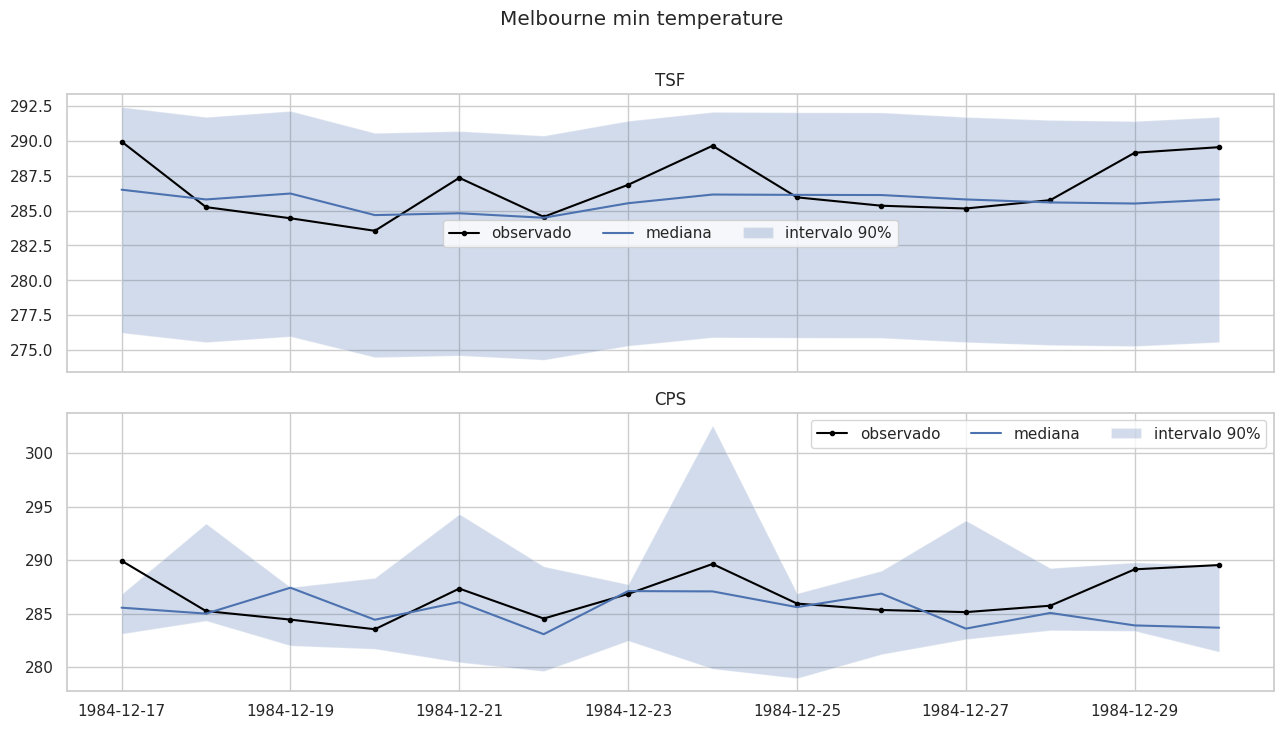

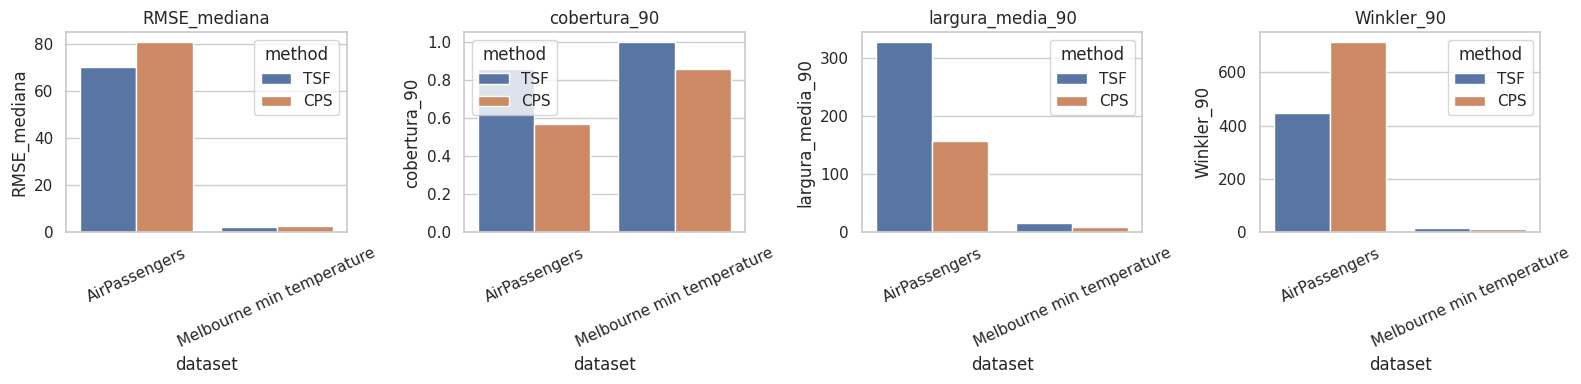

In [5]:
for dataset_name in datasets:
    plot_intervals(
        {method: predictions[(dataset_name, method)] for method in ["TSF", "CPS"]},
        dataset_name,
    )

metric_cols = ["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metric_cols):
    sns.barplot(resultados, x="dataset", y=metric, hue="method", ax=ax)
    ax.tick_params(axis="x", rotation=25); ax.set_title(metric)
plt.tight_layout()

In [6]:
def winners(frame):
    rows = []
    for dataset, part in frame.groupby("dataset"):
        target = 0.90
        rows.append({
            "dataset": dataset,
            "menor_RMSE": part.loc[part.RMSE_mediana.idxmin(), "method"],
            "cobertura_mais_próxima_90%": part.loc[(part.cobertura_90-target).abs().idxmin(), "method"],
            "menor_Winkler": part.loc[part.Winkler_90.idxmin(), "method"],
            "fit_mais_rápido": part.loc[part.fit_s.idxmin(), "method"],
        })
    return pd.DataFrame(rows)

display(winners(resultados))
print("Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.")

,dataset,menor_RMSE,cobertura_mais_próxima_90%,menor_Winkler,fit_mais_rápido
0,AirPassengers,TSF,TSF,TSF,TSF
1,Melbourne min temperature,TSF,CPS,CPS,TSF


Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.


## Reprodutibilidade e ressalvas

- Não há geração de dados sintéticos. As URLs/fontes estão explícitas no notebook.
- Resultados dependem de hardware, versões e da janela temporal escolhida.
- M5 exige aceitar as regras da competição e autenticar o Kaggle uma única vez.
- TSF é paramétrico; CPS usa resíduos conformais empíricos. Nenhum método domina necessariamente em todos os critérios.